----

# Chicago Taxi Trip Analysis
 This project analyzes taxi trips in Chicago to identify demand patterns and evaluate if wether rainy saturdays affect travel duration to O'Hare Airport


### We want to answer two questions:
* Which taxi companies dominate the market?
* Do rainy saturdays increase trip duration to the airport?


# DATA DESCRIPTION
companies_trips.csv — trips per taxi company

chic_neighborhood.csv — dropoff frequency per neighborhood

airport_trips.csv — trip duration and weather conditions

In [1]:
# Automatically locate project folders so the notebook works on any computer
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / "data"


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [3]:
df_companies = pd.read_csv('../data/companies_trips.csv')
df_neighborhoods = pd.read_csv('../data/chic_neighborhoods.csv')
df_trips = pd.read_csv('../data/airport_trips.csv')



### Load datasets and verify structure

In [4]:
# Dataset Structure
df_companies.info()


<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [5]:
# First Rows
df_companies.head(5)



,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [6]:
# Statical Summary
df_companies.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


# The distribution of trips per company is highly skewed.
The median  company performs only 178 trips while the mean exceeds 2,100. indicating the presence of a few dominant companies controlling most of the market demand.
This suggests a strong market concentration rather than a competitive distribution.

In [7]:
df_neighborhoods.info()


<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


In [8]:
df_neighborhoods.head(5)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [9]:
df_neighborhoods.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


## The distribution of trips is highly right-skewed: the mean (599) is more than 10 times the median (52), indicating that a small number of neighborhoods concentrate the majority of trips.
Therefore, the average is not representative of a typical location, and demand is geographically concentrated rather than evenly distributed.

In [10]:
# 5) Top 10 neighborhoods by average_trips (descending)
top10_neigh = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)
print(top10_neigh)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


### "The names of the top locations suggest transportation hubs and commercial areas, indicating that taxi demand is likely associated with commuting and tourism activity."

In [11]:
top = df_companies.sort_values('trips_amount', ascending=False).head(15)
print(top)

                            company_name  trips_amount
0                              Flash Cab         19558
1              Taxi Affiliation Services         11422
2                       Medallion Leasin         10367
3                             Yellow Cab          9888
4        Taxi Affiliation Service Yellow          9299
5              Chicago Carriage Cab Corp          9181
6                           City Service          8448
7                               Sun Taxi          7701
8              Star North Management LLC          7455
9      Blue Ribbon Taxi Association Inc.          5953
10               Choice Taxi Association          5015
11                            Globe Taxi          4383
12             Dispatch Taxi Affiliation          3355
13             Nova Taxi Affiliation Llc          3175
14  Patriot Taxi Dba Peace Taxi Associat          2235


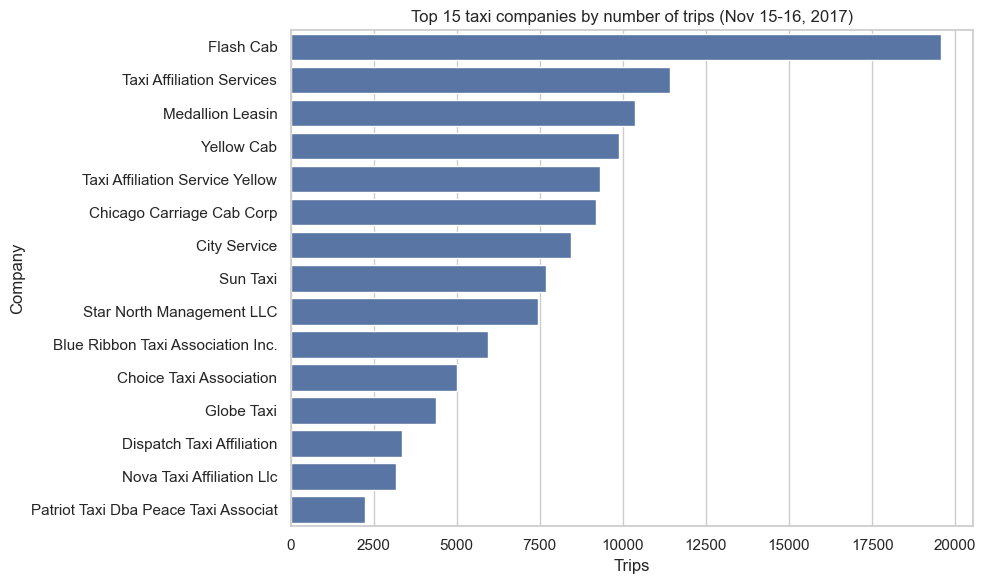

In [12]:


plt.figure(figsize=(10,6))
sns.barplot(data=top, x='trips_amount', y='company_name')
plt.title('Top 15 taxi companies by number of trips (Nov 15-16, 2017)')
plt.xlabel('Trips')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


### The taxi market is highly concentrated, with a small number of companies capturing the majority of trips. The distribution suggests structural advantages rather than organic competition (e.g., dispatch networks, contracts, or geographic dominance).

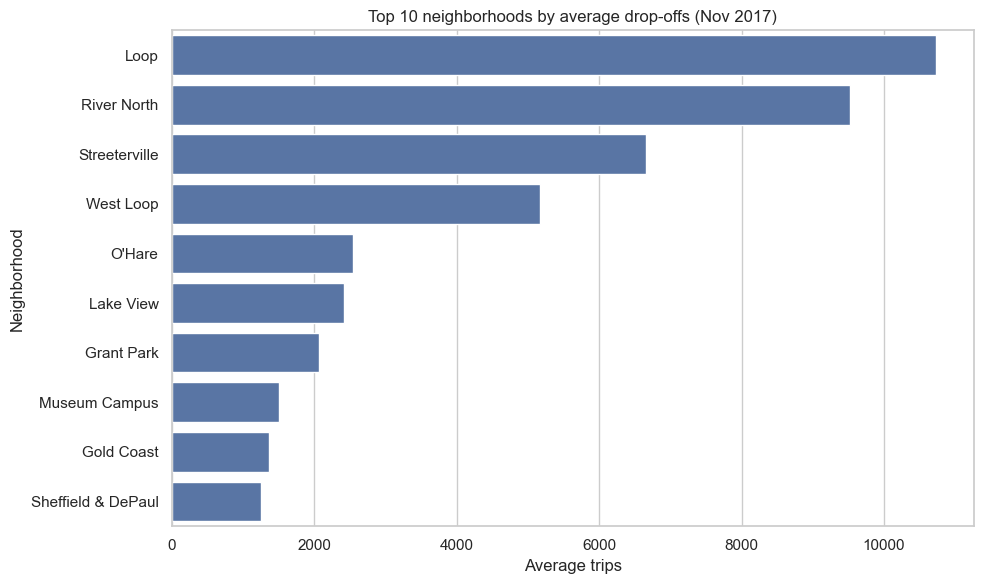

In [13]:
# b) Top 10 neighborhoods by average_trips
plt.figure(figsize=(10,6))
sns.barplot(data=top10_neigh, x='average_trips', y='dropoff_location_name')
plt.title('Top 10 neighborhoods by average drop-offs (Nov 2017)')
plt.xlabel('Average trips')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()


# Taxi demand is driven by activity hubs rather than residential density.


### The names of the top locations suggest transportation hubs and commercial areas, indicating that taxi demand is likely associated with commuting and tourism activity.



# Market structure Insight
the concentration of trips among a few taxi companies, combined with the spatial concentration of demand in specific neighborhoods(business and transport hubs), suggests that competitive advantage in this market is likely location-based rather than price-based.

Companies capturing high-traffic zones (downtown and airport areas) gain structural demand access, explaining the extreme skew in trip distribution.

### Hypothesis Testing
## Hypothesis to evaluate 'The average duration of trips from the Loop to O'HARE International Airport changes on saturdays under bad weather conditions.'

# H0 Null Hypothesis : 'The mean trip duration on Saturdays with bad weather is different from the mean trip duration on Saturdays with good weather.'

# H1 Alternative Hypothesis: 'The mean trip duration on Saturday is different from the mean trip durations on Saturday with GOOD weather conditions'.



In [14]:
import pandas as pd
from scipy.stats import ttest_ind

In [15]:
df_trips.info() # Check structure


<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 25.2 KB


In [16]:
df_trips.head(10) # First rows

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0
7,2017-11-18 11:00:00,Good,2280.0
8,2017-11-11 14:00:00,Good,2460.0
9,2017-11-11 12:00:00,Good,2040.0


In [17]:
df_trips = df_trips[df_trips.duration_seconds > 0] # Remove invalid durations

In [18]:
df_trips['start_ts'] = pd.to_datetime(df_trips['start_ts']) #convert timestamps and extract by name 
df_trips['day'] = df_trips['start_ts'].dt.day_name()

In [19]:
# Filetering only saturday days
saturday = df_trips[df_trips['day'] == 'Saturday']

In [20]:
#Split data by weather condition
good_weather = saturday[saturday['weather_conditions'] == 'Good']['duration_seconds']
bad_weather  = saturday[saturday['weather_conditions'] == 'Bad']['duration_seconds']

In [21]:
# 5. Print basic information
print("Trips with GOOD weather:", len(good_weather))
print("Trips with BAD weather:", len(bad_weather))
print("Mean duration GOOD:", good_weather.mean())
print("Mean duration BAD :", bad_weather.mean())

Trips with GOOD weather: 882
Trips with BAD weather: 180
Mean duration GOOD: 2013.2789115646258
Mean duration BAD : 2427.2055555555557


In [22]:
#hypotesis test
stat, p =ttest_ind(good_weather,bad_weather,equal_var=False)

In [23]:

print("\nT-statistic:", stat)
print("P-value:", p)


T-statistic: -6.979328835930791
P-value: 2.417359047158559e-11


In [24]:
alpha = 0.05  # significance level

if p < alpha:
    print("\n📌 RESULT: Reject H0 → Weather *does* affect trip duration on Saturdays.")
else:
    print("\n📌 RESULT: Fail to reject H0 → No evidence of change in trip duration.")


📌 RESULT: Reject H0 → Weather *does* affect trip duration on Saturdays.


### Bad weather significantly increases trip duration from the Loop to O'HARE on Saturdays, likely due to reduced traffic speed and congestion effects during adverse conditions.

## Hypothesis testing
the evaluated hypothesis:
'The average duration of trips from the Loop to O'Hare International Airport changes on Saturdays under adverse weather conditions'.
Using a significance level of 0.05, two groups of Saturday trips were compared. GOOD and Bad weather.

A Welch's two sample t-test was applied to account for unequal variances and different sample sizes.

# RESULTS

t-statistic = −6.98

p-value = 2.42e-11

Since the p-value is far below alpha, we reject the null hypothesis (H₀).
## Interpretation

There is a strong statistical evidence that weather conditions significantly affect trip duration on Saturdays.
Trips during BAD WEATHER take longer on average compared to trips under GOOD WEATHER conditions.This suggest that adverese weather introduces systematic delays, likely caused by lower traffic speed and increased congestion.
From a business perspective, this insight is useful for improving ETA predictions, planning a driver availability, and adjusting dynamic pricing strategies during a weekend periods with poor weather conditions.